# Example use for single 
## save data

In [ ]:
from Base.BaseDataHelper import BaseDataHelper
from MarketData.FundList import Fund
import Globals.Functions as gf
import Globals.Variables as gv

fund = Fund(isin="GB00B5N99561", full_name="Artemis Global Income Fund Inc")

fromYahoo = True
data = gf.get_data(fund, gv.start_date, gv.end_date, fromYahoo)
helper = BaseDataHelper("/Data/Yahoo/", fund.full_name + "_" + gv.start_date + "_" + gv.end_date + ".csv", data)
helper.save_data_frame()

[*********************100%***********************]  1 of 1 completed


# Plot 

[*********************100%***********************]  1 of 1 completed


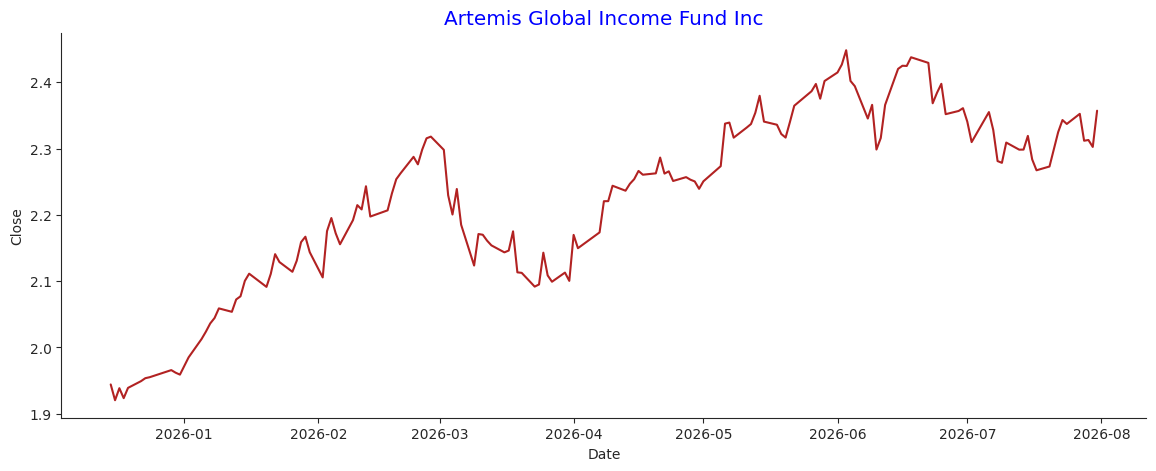

Mean:  2.2282696095379917
Absolute Growth:  17.522846475889626
Growth on Mean:  5.470125447627916
Volatility:  0.00757519535199778


In [ ]:
from MarketData.MarketDataHelper import MarketDataHelper
from MarketData.FundList import Fund
from MarketData.MarketDataPlotter import MarketDtaPlotter
from MarketData.FundDataAnalyser import FundAnalyser
import Globals.Functions as gf
import Globals.Variables as gv


try:
  fund = Fund(isin="GB00B5N99561", full_name="Artemis Global Income Fund Inc")
  # Can be much quicker to save data first for multiple runs
  fromYahoo = True
  data = gf.get_data(fund, gv.start_date, gv.end_date, fromYahoo)
  data = data.reset_index()
  # yfinance returns MultiIndex columns (Price, Ticker); flatten so 'Date'/'Close' are plain columns
  data.columns = data.columns.get_level_values(0)
  helper = MarketDataHelper(data, gv.start_date, gv.end_date)
  fund.set_data_helper(helper)
  plotter = MarketDtaPlotter(helper)
  plotter.plot_sns("Date", "Close", fund.full_name)
except Exception as e:
  print("An error occurred: ", e)

try:
  analyser = FundAnalyser(fund)
  mean = analyser.close_mean
  absGrowth = analyser.get_abs_growth()
  growthOnMean = analyser.get_growth_on_mean()
  vol = analyser.get_volatility()
  fund.set_indicators(mean, absGrowth, growthOnMean, vol)
except Exception as e:
  print("An error occurred: ", e)
finally:
  print("Mean: ", mean)
  print("Absolute Growth: ", absGrowth)
  print("Growth on Mean: ", growthOnMean)
  print("Volatility: ", vol)

fund.set_indicators(mean, absGrowth, growthOnMean, vol)

#Example of Excel generation 

In [ ]:
from MarketData.FundList import FundList
import Globals.Functions as gf
import Globals.Variables as gv
from Report.ReportGenerator import FundReportGenerator

fundList = FundList()
gf.populate_all_fund_data(gv.start_date, gv.end_date, fundList)
# gf.plot_all_fund_data(fundList)
fundList = gf.get_all_fund_indicators(fundList)
reportGenerator = FundReportGenerator(fundList)
reportGenerator.write_to_excel("FundReport")

: 